<a href="https://colab.research.google.com/github/amakello/Kujenga/blob/main/Akello_Odundo_Kenya_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Happiness Data Linear Regression

Akello Odundo

Kenya

Assignment 1

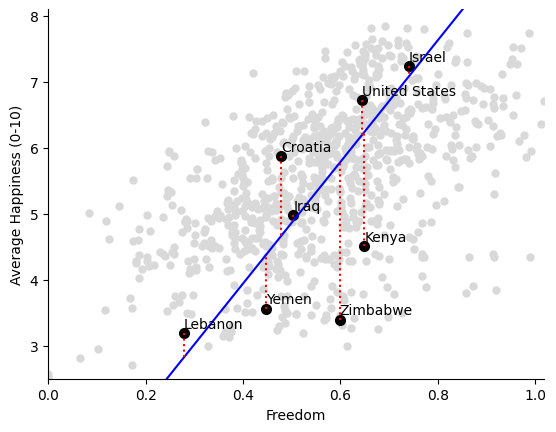

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plotData(df,x,y):
    fig,ax=plt.subplots(num=1)
    ax.plot(x,y, data=df, linestyle='none', markersize=5, marker='o', color=[0.85, 0.85, 0.85])
    for country in ['United States','Lebanon','Croatia','Kenya','Israel','Iraq','Yemen','Zimbabwe']:
        ci=np.where(df['Country name']==country)[0][0]
        ax.plot(  df.iloc[ci][x],df.iloc[ci][y], linestyle='none', markersize=7, marker='o', color='black')
        ax.text(  df.iloc[ci][x],df.iloc[ci][y]+0.08,  country)

    ax.set_yticks(np.arange(11,step=1))
    ax.set_ylabel('Average Happiness (0-10)')
    ax.set_xlabel(x)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(np.min(df[x]),np.max(df[x])) # Adjusted x-lim to be dynamic based on the x variable
    ax.set_ylim(2.5,8.1)
    return fig,ax

# Assign the happy dataframe to df and rename columns to match the code
df = happy.copy()
df = df.rename(columns={'Explained by: Freedom to make life choices': 'Freedom', 'Life evaluation (3-year average)': 'Happiness'})

# Calculate best-fit parameters for Freedom vs Happiness
df=df.assign(SquaredFreedom=np.power(df['Freedom'],2))
df=df.assign(HappinessFreedom=df['Freedom'] * df['Happiness'])
m_best = np.sum(df['HappinessFreedom'])/np.sum(df['SquaredFreedom'])
k_best = np.mean(df['Happiness']) - m_best*np.mean(df['Freedom'])

# Generate points for the fitted line
# Using Freedom's range for the line plotting
Freedom_Range=np.arange(np.min(df['Freedom'])-5, np.max(df['Freedom'])+5, step=0.01) # Extend range slightly
Happiness_Line= m_best*Freedom_Range + k_best

# Create the plot
fig,ax=plotData(df,'Freedom','Happiness')
ax.plot(Freedom_Range, Happiness_Line, linestyle='-', color='blue')

# Add vertical dotted lines for the residuals of highlighted countries
df=df.assign(Predicted=np.array(m_best*df['Freedom']+k_best))
for country in ['United States','Lebanon','Croatia','Kenya','Israel','Iraq','Yemen','Zimbabwe']:
    ci=np.where(df['Country name']==country)[0][0]
    ax.plot(  [df.iloc[ci]['Freedom'],df.iloc[ci]['Freedom']] ,[ df.iloc[ci]['Happiness'],df.iloc[ci]['Predicted']] ,linestyle=':', color='red')

plt.show()

Happiness Data for the year 2024 was used.

Based on our linear regression model, there is a positive correlation between 'Freedom to make life choices' (denoted by 'Freedom') and 'Happiness' (denoted by 'Average Happiness'). The calculated slope of the line is approximately 7.27. This means that, roughly, an increase in freedom by 0.1375 (which is 1 divided by the slope) units is associated with one extra point of happiness on the 0-10 scale.

It is important to remember that correlation does not equal causation. While countries with higher levels of perceived freedom tend to report higher happiness scores, this doesn't automatically mean that freedom causes happiness. There could be other underlying factors influencing both, or even a reverse causality. Happier societies might naturally culture environments that promote greater individual freedoms.

The data simply shows a relationship, not necessarily a direct cause-and-effect link. For instance, the United States and Kenya freedom scores are relativley similar but their happiness scores are vastly different. Basically, while both countries have almost the same level of freedom, United States is much happier than Kenya.